In [213]:
import numpy as np
import pandas as pd
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 

from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import MinMaxScaler, StandardScaler

def adf_test(series, title=""):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f"Augmented Dickey-Fuller Test: {title}")
    result = adfuller(
        series.dropna(), autolag="AIC"
    )  # .dropna() handles differenced data

    labels = ["ADF test statistic", "p-value", "# lags used", "# observations"]
    out = pd.Series(result[0:4], index=labels)

    for key, val in result[4].items():
        out[f"critical value ({key})"] = val

    print(out.to_string())  # .to_string() removes the line "dtype: float64"

    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

def total_mean_error(predictions):
    mean_error = []

    for i in range(len(predictions)):
        if df[3003858507][i] == 0:
            error_value = np.abs((predictions[i]-0.01)/(0.01))*100
            mean_error.append(error_value)
            print(
                f"predição={predictions[i]}, esperado={df[3003858507][i]}, erro={error_value}%"
            )
        else:
            error_value = np.abs((predictions[i]-df[3003858507][i])/(df[3003858507][i]))*100
            mean_error.append(error_value)
            print(
                f"predição={predictions[i]}, esperado={df[3003858507][i]}, erro={error_value}%"
            )

    aux = 0

    for i in range(len(mean_error)):
        if mean_error[i] > 200:
            aux = aux
        else:
            aux = mean_error[i] + aux

    final_mean = aux/len(mean_error)

    print(f"Erro percentual médio = {final_mean}%")

In [214]:
# Lendo os dados
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"
df

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
2019-11-01,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01,2854.0,7440.0,280.0,1200.0,2480.0


In [215]:
print(df.shape)

(45, 5)


In [216]:
df = pd.concat([df, df])
with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.precision",
    3,
):
    print(df)

           3003858507 3001084033 3011373971 3001449459 3011504476
idx                                                              
2019-06-01     1246.0     7160.0      440.0      960.0     1560.0
2019-07-01     1081.0     6520.0      600.0      920.0     1280.0
2019-08-01     1184.0     6840.0      680.0     1120.0     1360.0
2019-09-01     1549.0     7440.0      760.0     1040.0     1680.0
2019-10-01     2045.0     6920.0      560.0     1120.0     1680.0
2019-11-01     4017.0     6920.0      520.0     1240.0     2920.0
2019-12-01     2386.0     7240.0      320.0     1000.0     1960.0
2020-01-01     4239.0     6560.0      440.0     1120.0     2280.0
2020-02-01     2854.0     7440.0      280.0     1200.0     2480.0
2020-03-01     3208.0     7440.0      320.0     1360.0     2240.0
2020-04-01     1048.0     5640.0      440.0     1080.0     1480.0
2020-05-01     1313.0     4880.0        0.0     1040.0     1280.0
2020-06-01     1174.0     5080.0        0.0     1320.0     1240.0
2020-07-01

In [217]:
new_index = pd.date_range(start=df.index.min(), periods=len(df), freq="MS")

df.index = new_index

df

,3003858507,3001084033,3011373971,3001449459,3011504476
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
...,...,...,...,...,...
2026-07-01,1216.0,7440.0,920.0,1000.0,2280.0
2026-08-01,1335.0,7240.0,360.0,840.0,2000.0
2026-09-01,1317.0,7960.0,680.0,880.0,2160.0
2026-10-01,2367.0,5880.0,800.0,840.0,2120.0


In [218]:
auto_arima(
    df[3003858507].astype(float),
    m=12,
    seasonal=True,
).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   90
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -735.575
Date:                Sun, 18 Feb 2024   AIC                           1477.150
Time:                        14:44:06   BIC                           1484.650
Sample:                    06-01-2019   HQIC                          1480.175
                         - 11-01-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    790.0734    311.147      2.539      0.011     180.237    1399.909
ar.L1          0.6332      0.118      5.356      0.000       0.402       0.865
sigma2      7.337e+05   1.23e+05      5.949      0.000    4.92e+05    9.75e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 4.82
Prob(Q):                              0.84   Prob(JB):                         0.09
Heteroskedasticity (H):               0.75   Skew:                             0.56
Prob(H) (two-sided):                  0.45   Kurtosis:                         3.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [219]:
train = df.iloc[:80]
test = df.iloc[80:]

test = test.astype(float)
train = train.astype(float)

model = SARIMAX(
    train[3003858507].astype(float), order=(1, 0, 0), seasonal_order=(5, 1, 7, 12)
)
results = model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           14     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.21448D+00    |proj g|=  3.51988D-01


 This problem is unconstrained.



At iterate    5    f=  7.10068D+00    |proj g|=  9.13930D-03

At iterate   10    f=  7.10015D+00    |proj g|=  9.90355D-04

At iterate   15    f=  7.09992D+00    |proj g|=  5.61155D-03

At iterate   20    f=  7.09987D+00    |proj g|=  3.14757D-04

At iterate   25    f=  7.09984D+00    |proj g|=  8.69974D-04

At iterate   30    f=  7.09983D+00    |proj g|=  3.08458D-04

At iterate   35    f=  7.09974D+00    |proj g|=  4.06418D-03

At iterate   40    f=  7.09946D+00    |proj g|=  6.92931D-03

At iterate   45    f=  7.09931D+00    |proj g|=  1.86723D-03

At iterate   50    f=  7.09920D+00    |proj g|=  2.08393D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

In [220]:
start = len(train)
end = len(train) - 1
augmented_predictions = results.predict(
    start=0, end=end, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

augmented_future_predictions = results.predict(
    start=end, end=end + 44, dynamic=False, typ="levels"
).rename("SARIMA Future Predictions")

total_mean_error(augmented_predictions)

predição=0.0, esperado=1246.0, erro=100.0%
predição=574.7303742830067, esperado=1081.0, erro=46.83345288778847%
predição=560.9877528736878, esperado=1184.0, erro=52.61927762891151%
predição=599.9495183190969, esperado=1549.0, erro=61.268591457772956%
predição=758.9651904113281, esperado=2045.0, erro=62.88678775494729%
predição=994.0797664606708, esperado=4017.0, erro=75.25317982423026%
predição=1863.1989886202473, esperado=2386.0, erro=21.911190753552084%
predição=1326.5234009566425, esperado=4239.0, erro=68.70669023456847%
predição=1990.4630684768792, esperado=2854.0, erro=30.257075386234085%
predição=1500.1142054307631, esperado=3208.0, erro=53.2383352421832%
predição=1502.1521369165494, esperado=1048.0, erro=43.335127568373025%
predição=517.9472062522028, esperado=1313.0, erro=60.55238337759309%
predição=1524.3449376442777, esperado=1174.0, erro=29.841987874299637%
predição=852.1328520666791, esperado=799.0, erro=6.649918906968599%
predição=781.0900221071386, esperado=952.0, erro=17

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

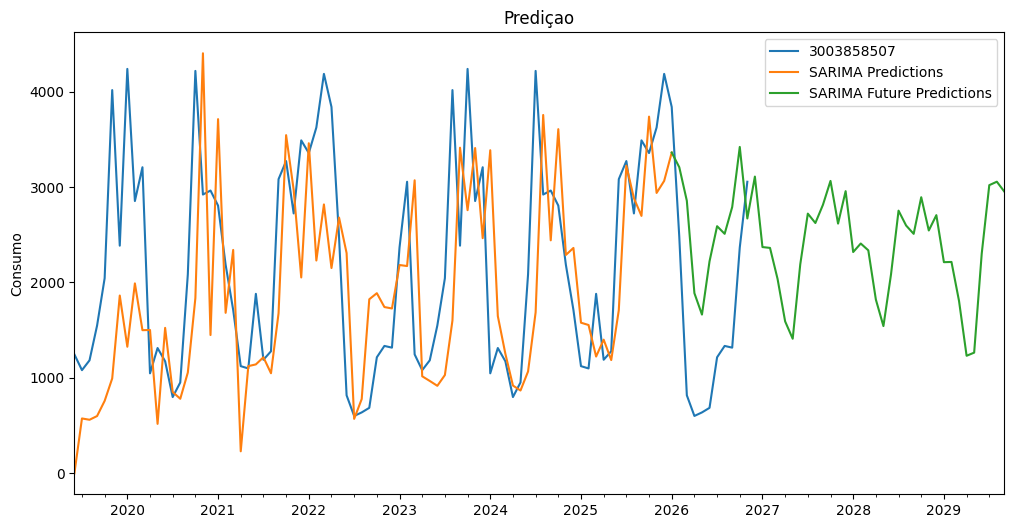

In [221]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df[3003858507].plot(legend=True, figsize=(12, 6), title=title)
augmented_predictions.plot(legend=True)
augmented_future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)